 # ORAIMO SALES FORECASTING (TIME SERIES ANALYSIS)
>Forecasting Monthly Sales for November 2024 Based on Historical Sales Data

<img src="logo.png" alt="Oraimo Logo" width="300"/>

## Everything Data Group Members
> 1. Calvince Kaunda
> 2. Gloryann Otieno 
> 3. Peter Nyakundi
> 4. Samuel Marimbi
> 5. Sanayet Sankaine
  
## Project Summary
>This project focuses on building a time series forecasting model for Oraimo, a consumer electronics brand. Using sales data from January to October 2024, we aim to predict sales for November 2024. The project will help improve demand planning, minimize stockouts and overstocking, and enable more informed inventory and marketing decisions.


## 1. Business Understanding
>Oraimo faces demand fluctuations across different cities and product categories. Without accurate forecasting, the company risks overstocking or understocking its inventory, leading to losses from unsold stock or missed sales opportunities. Analyzing sales data is crucial for assessing business performance and identifying improvement areas. Sales forecasting goes a step further by predicting future demand, which helps optimize inventory management, workforce planning and supply chain decisions.


### Objectives
>- To build a recommender system that forecasts sales for Oraimo across different cities and product categories.
>- To analyze historical sales data to understand demand patterns and fluctuations.
>- To implement a forecasting model that predicts sales for the upcoming month, reducing the risks of overstocking and understocking.
>- To optimize inventory management and resource allocation by providing more accurate future demand insights.
 
### Stakeholders
>- Oraimo Management Team – for strategic planning and decision-making
>- Sales and Inventory Teams – to improve stock management and meet customer demand
>- Supply Chain & Logistics Teams – for efficient distribution and resource allocation
>- Retailers & Shop Managers – to ensure timely product availability
>- Data & Business Analysts – to monitor performance and model accuracy

## Metrics of Success
>- Identify clear and actionable sales trends across cities, shops, and product types.
>- Ensure the final forecast aligns with observed historical patterns and seasonal demand shifts.
>- Provide insights that inform inventory and resource planning for November 2024.
>- Achieve a forecasting model with:

## 2. Data Understanding
The Oraimo Sales dataset is from a Data Science community, DataVerse. The dataset contains historical sales records from January to October 2024 by Oraimo across multiple shops across the country.The dataset contains 19,802 rows and 14 columns.

#### Features:
**year** — Year of the sale (2024)  
**month** — Month name of the sale  
**date** — Raw string of the sale date  
**week** — Week number in the year  
**city** — Name of the city where the sale occurred  
**shop_name** — Name of the specific shop  
**model** — Specific product model sold  
**type** — Product type/category  
**quantity** — Number of units sold  
**sales_price** — Selling price per unit  
**amount** — Total revenue from the sale (quantity × sales_price)  
**source** — Sales channel 
**proper_date** — Cleaned datetime format of the sale  
**city_2** — Additional city labeling 




>### 2.1 Load the dataset
We begin by loading the dataset into a pandas DataFrame for further processing and analysis.This allows us to inspect the structure of the dataset, understand what we are working with and begin cleaning and transforming the data.

In [1]:
#import relevant libraries
import pandas as pd

data = pd.read_csv("oraimo_sales.csv")

#vire first few rows of dataset
data.head()

,year,month,date,week,city,shop_name,model,type,quantity,sales_price,amount,source,proper_date,city_2
0,2024.0,JANUARY,02/Jan,1.0,NAIROBI,ABDI WALI HIISH,OCD-C53,CABLE,15,135.0,2025.0,NOORTECH,2024-01-02,NAIROBI
1,2024.0,JANUARY,02/Jan,1.0,NAIROBI,ABDI WALI HIISH,OCD-M53,CABLE,20,85.0,1700.0,NOORTECH,2024-01-02,NAIROBI
2,2024.0,JANUARY,02/Jan,1.0,NAIROBI,ABDI WALI HIISH,OCD-M53,CABLE,200,85.0,17000.0,NOORTECH,2024-01-02,NAIROBI
3,2024.0,JANUARY,02/Jan,1.0,NAIROBI,ABDI WALI HIISH,OCW-U66S+C53,CHARGER KIT,15,385.0,5775.0,NOORTECH,2024-01-02,NAIROBI
4,2024.0,JANUARY,02/Jan,1.0,NAIROBI,ABDI WALI HIISH,OCW-U66S+C53,CHARGER KIT,15,385.0,5775.0,NOORTECH,2024-01-02,NAIROBI


>### 2.2 Dataframe Shape
We evaluate the shape of our dataset to identify the number of rows and columns.  

In [2]:
#shape of dataframe
print(f"Rows : {data.shape[0]}")
print(f"Columns : {data.shape[1]}")

Rows : 19802
Columns : 14


>### 2.3 Dataset Information
We examine the basic structure of the data to understand its composition, including the number of entries, columns, data types and missing values. This will help us determine how to clean and preprocess the data.

In [3]:
#general overview of the dataframe
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19802 entries, 0 to 19801
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         19800 non-null  float64
 1   month        19801 non-null  object 
 2   date         19801 non-null  object 
 3   week         19801 non-null  float64
 4   city         19801 non-null  object 
 5   shop_name    19801 non-null  object 
 6   model        19800 non-null  object 
 7   type         19781 non-null  object 
 8   quantity     19802 non-null  int64  
 9   sales_price  19802 non-null  float64
 10  amount       19802 non-null  float64
 11  source       19801 non-null  object 
 12  proper_date  19802 non-null  object 
 13  city_2       19801 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 2.1+ MB


>### 2.4 Dataset General Statistics
In this step, we generate descriptive statistics of the dataset to understand the distribution of numerical features. This includes measures like mean, standard deviation, minimum and maximum values for each numerical column.

In [4]:
#general statistics
data.describe()

,year,week,quantity,sales_price,amount
count,19800.0,19801.000000,19802.000000,19802.000000,1.980200e+04
mean,2024.0,22.855209,135.822442,291.815469,4.052269e+04
std,0.0,11.644828,395.830110,159.611966,9.452771e+04
min,2024.0,1.000000,1.000000,0.000000,0.000000e+00
25%,2024.0,13.000000,12.000000,161.000000,1.350000e+04
50%,2024.0,25.000000,50.000000,330.000000,1.925000e+04
75%,2024.0,33.000000,112.000000,330.000000,3.500000e+04
max,2024.0,40.000000,30240.000000,1000.000000,6.773760e+06


>### 2.5 Check for missing values
We check for missing values in the dataset and evaluate their number to decide on the best way for handling them

In [5]:
#check for missing values
print(f"The dataset contains {data.isnull().sum().sum()} missing values")

The dataset contains 32 missing values


>### 2.6 Check for duplicate values
We evaluate the duplicates present in our dataset in order to decide on the proper handling method for duplicates

In [6]:
print(f"The dataset contains {data.duplicated().sum()} duplicate values")

The dataset contains 299 duplicate values


## 3. Data cleaning
In this step, we clean the dataset by handling missing values, duplicate values, standardizing data, dropping irrelevant columns and addressing any other issues to ensure that the data is reliable and ready for further analysis.

>### 3.1 Handling missing values and duplicates
Our dataset does not contain a lot of duplicates and missing values hence the most appropriate method for handling them is to drop the values as they do not represent a large portion of the dataset.

In [7]:
#drop duplicates and re-evaluate shape

df = data.drop_duplicates()

df.shape

(19503, 14)

In [8]:
#drop missing values 
df = df.dropna(axis = 0)

#re-evaluate shape after dropping the rows
df.shape

(19480, 14)

>### 3.2 Standardize the `month` and `type` column
Some entries in the `month` and `type`columns are in lowercase while others are in uppercase. To ensure consistency and avoid issues during analysis, we convert all values in both columns to uppercase.

In [9]:
df["month"] = df["month"].str.upper()
df["type"] = df["type"].str.upper()

>### 3.3 Rename relevant columns and drop irrelevant ones
In this section,we rename the `type` column to `product_type` for better readability and understanding.  
Columns such as `city_2`, `year`, `source`, `shop_name`, `proper_date` and `model` are irrelevant and need to be dropped.

In [10]:
#maintain relevant columns
df["date"] = df["proper_date"]

#rename type column
df = df.rename(columns = {"type":"product_type"})


df = df.drop(["city_2","year","proper_date","source","shop_name","model"], axis=1)
df.head()

,month,date,week,city,product_type,quantity,sales_price,amount
0,JANUARY,2024-01-02,1.0,NAIROBI,CABLE,15,135.0,2025.0
1,JANUARY,2024-01-02,1.0,NAIROBI,CABLE,20,85.0,1700.0
2,JANUARY,2024-01-02,1.0,NAIROBI,CABLE,200,85.0,17000.0
3,JANUARY,2024-01-02,1.0,NAIROBI,CHARGER KIT,15,385.0,5775.0
5,JANUARY,2024-01-02,1.0,NAIROBI,CHARGER KIT,5,385.0,1925.0


>### 3.4 Evaluate entries in `city` and `product_type` columns
Some entries in the `city` and `product_type` columns have spelling errors.  
We begin by evaluating the entries to idenitfy where we have spelling errors and handle the inconsistencies.

In [11]:
#check city and product type columns
print(df["city"].unique())
print("")
print(df["product_type"].unique())

['NAIROBI' 'NYERI' 'MOMBASA' 'NAIROBI  OSMAN' 'KILIFI' 'KARATINA'
 'ELDORET' 'NAROK' 'BUNGOMA' 'KAKAMEGA' 'NAIROBI  MERCY' 'KITALE'
 'KERUGOYA' 'NANYUKI' 'RONGO' 'MACHAKOS' 'RUIRU' 'NAKURU' 'RUNYENJES'
 'KAPSABET' 'KIAMBU' 'MALINDI' 'NAIVASHA' 'TANZANIA' 'MERU' 'KISUMU'
 'WAJIR' 'THIKA' 'LITEIN' 'BOMET' 'SIRARE' 'KISII' 'KERICHO' 'MOYALE'
 'BAMBURI' 'SIAYA' 'UKUNDA' 'KITUI' 'GARISSA' 'OLJOROROK' 'RONGAI' 'EMBU'
 'GARISA' 'NYAHURURU' 'MALABA' 'WESTERN' 'CENTRAL' 'MIGORI' 'VOI'
 'RUIRU NAIROBI' 'KITUI NAIROBI' 'NAIROB  OSMAN' 'NAIROBI  MECY'
 'NAIRROBI  MERCY' 'NAIRIBO  MERCY' 'ISIBANIA' 'KAPENGURIA' 'CABANAS'
 'NAIROBI   MERCY' 'UGANDA' 'NAIROBI MERCY' 'KITENGELA' 'MAUA' 'NAIROB'
 'NAROBI' 'CHOGORIA' 'TOPAZ MOBILE ACCESSORIESNAIROBI' 'DIANI' 'MMMBASA'
 'MOYALE SHOP' 'BURUBURU' 'MMMBAMA' 'KARIS KADIRO' 'NYALI' 'LANGATA'
 'LIKONI' 'NAROBI  OSMAN' 'EXCEL' 'NAIROBI OSMAN' 'KIBWEZI' 'NANYUKU'
 'NAROBI  MERCY' 'NAIROBIOSMAN' 'RUNYEJES' 'KISIMU' 'NAIROB I OSMAN']

['CABLE' 'CHARGER KIT' 'EARPH

In the `city` column, we have entries such as Nairobi and Ruiru Nairobi  which need to be merged to a single entry:Nairobi,  
This also applies to the `product_type` column where there are mispellings and different variations of the same kind of product. Hence, we need to handle such inconsistencies.

In [12]:
#clean product_type column

df["product_type"] = df["product_type"].str.upper().replace({
    "CHARGERKIT.*|CHARGER.*|CAR CHAGER.*": "CHARGER KIT",
    "EARPHONES?.*": "EARPHONES",
    "WIRELESS EARPHONE": "EARPHONES",
    "CLIPPER.*": "CLIPPER",
    "POWER ?BANK.*": "POWER BANK",
    "FLASH(DISK|DRIVE).*": "FLASH DISK",
    "DATA CABLE|CABLE|IPHONE CABLE|DATA": "CABLE",
    "NECLESS|NECKLESS": "NECKLACE",
    "SHEIVER|SHAIVER": "SHAVER",
    "EXTENTION|EXTENSION": "EXTENSION CABLE",
    "BODY FAT SAID": "BODY FAT SCALE",
    "HEADPHONES|HEADSET BLUETOOTH": "HEADPHONES"
}, regex=True)


In [13]:
# Standardize 'City' column
city_cleaning_map = {
    # Nairobi variations
    'NAIROB': 'NAIROBI', 'NAROBI': 'NAIROBI', 'NAIROBI MERCY': 'NAIROBI',
    'NAIROBI  MERCY': 'NAIROBI', 'NAIROBI   MERCY': 'NAIROBI',
    'NAIRROBI  MERCY': 'NAIROBI', 'NAIRIBO  MERCY': 'NAIROBI',
    'NAIROB  OSMAN': 'NAIROBI', 'NAIROBI  OSMAN': 'NAIROBI',
    'NAIROB I OSMAN': 'NAIROBI', 'NAROBI  OSMAN': 'NAIROBI',
    'NAIROBI OSMAN': 'NAIROBI', 'NAIROBIOSMAN': 'NAIROBI',
    'RUIRU NAIROBI': 'NAIROBI', 'KITUI NAIROBI': 'NAIROBI',
    'TOPAZ MOBILE ACCESSORIESNAIROBI': 'NAIROBI','NAIROBI  MECY' : 'NAIROBI','NAROBI  MERCY' : 'NAIROBI', 'CABANAS': 'NAIROBI',

    # Nairobi estates to Nairobi
    'LANGATA': 'NAIROBI', 'KITENGELA': 'NAIROBI', 'BURUBURU': 'NAIROBI', 'RONGAI': 'NAIROBI',

    # Misspelled cities
    'MMMBASA': 'MOMBASA', 'MMMBAMA': 'MOMBASA',
    'KISIMU': 'KISUMU', 'RUNYEJES': 'RUNYENJES',
    'NANYUKU': 'NANYUKI', 'GARISA': 'GARISSA',

    # Coast towns to 'COAST'
    'MOMBASA': 'COAST', 'KILIFI': 'COAST', 'MALINDI': 'COAST',
    'UKUNDA': 'COAST', 'DIANI': 'COAST', 'NYALI': 'COAST',
    'LIKONI': 'COAST', 'BAMBURI': 'COAST', 'VOI': 'COAST',
    
    # Nyeri County
    'KARATINA': 'NYERI',
    # Migori County
    'RONGO': 'MIGORI', 'SIRARE': 'MIGORI', 'ISIBANIA': 'MIGORI', 
    #Kiambu 
    'RUIRU': 'KIAMBU', 'EXCEL': 'KIAMBU', 'THIKA': 'KIAMBU', 'OLJOROROK': 'NYAHURURU','LITEIN': 'KERICHO','MAUA': 'MERU', 'RUNYENJES': 'EMBU', 'MALABA': 'BUNGOMA', 'MOYALE SHOP': 'MOYALE' 
}

# Apply the cleaning map
df['city'] = df['city'].replace(city_cleaning_map)


In [14]:
#confirm changes
print(df["city"].unique())
print("")
print(df["product_type"].unique())

['NAIROBI' 'NYERI' 'COAST' 'ELDORET' 'NAROK' 'BUNGOMA' 'KAKAMEGA' 'KITALE'
 'KERUGOYA' 'NANYUKI' 'MIGORI' 'MACHAKOS' 'KIAMBU' 'NAKURU' 'EMBU'
 'KAPSABET' 'NAIVASHA' 'TANZANIA' 'MERU' 'KISUMU' 'WAJIR' 'KERICHO'
 'BOMET' 'KISII' 'MOYALE' 'SIAYA' 'KITUI' 'GARISSA' 'NYAHURURU' 'WESTERN'
 'CENTRAL' 'KAPENGURIA' 'UGANDA' 'CHOGORIA' 'MOMBASA' 'KARIS KADIRO'
 'KIBWEZI' 'RUNYENJES']

['CABLE' 'CHARGER KIT' 'EARPHONES' 'CAR CHARGER KIT' 'BATTERY' 'TRIMMER'
 'MEMORY CARD' 'AMLET' 'CONNECTOR' 'WIRELESS HEADSET'
 'WATCH CHARGING CABLE' 'SHAVER' 'TWS' 'SMART WATCH' 'POWER BANK'
 'WIRELESS SPEAKER' 'MIFI' 'SOCKET' 'ELECTRIC KETTLE' 'BLENDER'
 'WIRELESS KEYBOARD' 'HAND VACUUM CLEANER' 'STORAGE POWER' 'HAIR CLIPPER'
 'FLASH DISK' 'OPEN EAR' 'ELECTRIC FAN' 'CAR BRACKET' 'MOUSE' 'E-BIKE'
 'BODY FAT SCALE' 'POWERBOAT' 'SPEAKER' 'HEADPHONES' 'CLIPPER'
 'EXTENSION CABLE' 'MODULATOR CAR CHARGER KIT' 'KEYBOARD KIT' 'ORAIMO'
 'EARBUDS' 'AIRBUS' 'FREEPODS' 'NECKLACE' 'TUBFULS' 'SOLAR GENERATOR'
 'COMBO SET' 'EA

>### 3.5 Convert `date` column and set as index
The `date` column is first converted into a datetime format to ensure it's recognized as a proper timestamp. After that, it is set as the index of the DataFrame. This step is essential for conducting time series operations and analyses such as resampling or trend forecasting.

In [15]:
type(df["date"])

pandas.core.series.Series

In [16]:
#convert date column to date time
from datetime import datetime
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date", drop = True)

In [17]:
df.head()

,month,week,city,product_type,quantity,sales_price,amount
date,,,,,,,
2024-01-02,JANUARY,1.0,NAIROBI,CABLE,15,135.0,2025.0
2024-01-02,JANUARY,1.0,NAIROBI,CABLE,20,85.0,1700.0
2024-01-02,JANUARY,1.0,NAIROBI,CABLE,200,85.0,17000.0
2024-01-02,JANUARY,1.0,NAIROBI,CHARGER KIT,15,385.0,5775.0
2024-01-02,JANUARY,1.0,NAIROBI,CHARGER KIT,5,385.0,1925.0


>### 3.6 Group product_type column into 5 Categories 
Group product_type column into 5 categories to evaluate which category of products is most popular


In [18]:
df["product_type"].unique()

array(['CABLE', 'CHARGER KIT', 'EARPHONES', 'CAR CHARGER KIT', 'BATTERY',
       'TRIMMER', 'MEMORY CARD', 'AMLET', 'CONNECTOR', 'WIRELESS HEADSET',
       'WATCH CHARGING CABLE', 'SHAVER', 'TWS', 'SMART WATCH',
       'POWER BANK', 'WIRELESS SPEAKER', 'MIFI', 'SOCKET',
       'ELECTRIC KETTLE', 'BLENDER', 'WIRELESS KEYBOARD',
       'HAND VACUUM CLEANER', 'STORAGE POWER', 'HAIR CLIPPER',
       'FLASH DISK', 'OPEN EAR', 'ELECTRIC FAN', 'CAR BRACKET', 'MOUSE',
       'E-BIKE', 'BODY FAT SCALE', 'POWERBOAT', 'SPEAKER', 'HEADPHONES',
       'CLIPPER', 'EXTENSION CABLE', 'MODULATOR CAR CHARGER KIT',
       'KEYBOARD KIT', 'ORAIMO', 'EARBUDS', 'AIRBUS', 'FREEPODS',
       'NECKLACE', 'TUBFULS', 'SOLAR GENERATOR', 'COMBO SET',
       'EARPHONESS', 'HANDHELD VACUUM', 'OCD-X93', 'TWS EARPHONES',
       'SPACEPODS', 'NECK EARPHONES', 'BUDS', 'BATTERY 1000MAH',
       'NECKBAND WIRELESS', 'MEMORY'], dtype=object)

The 5 Categories Include;   
   - Power Devices  
   - Audio Devices  
   - Smart and Office Devices  
   - Personal Care  
   - Home Appliances  

In [19]:
categories = {
    # Power Devices
    'CHARGER KIT': 'Power Devices',
    'CAR CHARGER KIT': 'Power Devices',
    'MODULATOR CAR CHARGER KIT': 'Power Devices',
    'BATTERY': 'Power Devices',
    'BATTERY 1000MAH': 'Power Devices',
    'POWER BANK': 'Power Devices',
    'POWERBOAT': 'Power Devices',
    'STORAGE POWER': 'Power Devices',
    'SOLAR GENERATOR': 'Power Devices',
    'CONNECTOR': 'Power Devices',
    'WATCH CHARGING CABLE': 'Power Devices',
    'SOCKET': 'Power Devices',
    'EXTENSION CABLE': 'Power Devices',
    'EXTENTION': 'Power Devices',

    # Audio Devices
    'EARPHONES': 'Audio Devices',
    'EARPHONESS': 'Audio Devices',
    'TWS': 'Audio Devices',
    'TWS EARPHONES': 'Audio Devices',
    'WIRELESS HEADSET': 'Audio Devices',
    'HEADPHONES': 'Audio Devices',
    'EARBUDS': 'Audio Devices',
    'FREEPODS': 'Audio Devices',
    'OPEN EAR': 'Audio Devices',
    'SPACEPODS': 'Audio Devices',
    'BUDS': 'Audio Devices',
    'NECK EARPHONES': 'Audio Devices',
    'NECKBAND WIRELESS': 'Audio Devices',
    'SPEAKER': 'Audio Devices',
    'WIRELESS SPEAKER': 'Audio Devices',

    # Smart and Office Devices
    'SMART WATCH': 'Smart and Office Devices',
    'WIRELESS KEYBOARD': 'Smart and Office Devices',
    'KEYBOARD KIT': 'Smart and Office Devices',
    'MOUSE': 'Smart and Office Devices',
    'MEMORY CARD': 'Smart and Office Devices',
    'FLASH DISK': 'Smart and Office Devices',
    'MEMORY': 'Smart and Office Devices',
    'MIFI': 'Smart and Office Devices',
    'COMBO SET': 'Smart and Office Devices',
    'ORAIMO': 'Smart and Office Devices',
    'OCD-X93': 'Smart and Office Devices',
    'AIRBUS': 'Smart and Office Devices',
    'E-BIKE': 'Smart and Office Devices',

    # Personal Care
    'TRIMMER': 'Personal Care',
    'HAIR CLIPPER': 'Personal Care',
    'SHAVER': 'Personal Care',
    'SHAIVER': 'Personal Care',
    'BODY FAT SCALE': 'Personal Care',
    'HANDHELD VACUUM': 'Personal Care',
    'HAND VACUUM CLEANER': 'Personal Care',
    'NECKLACE': 'Personal Care',
    'AMLET': 'Personal Care',

    # Home Appliances
    'ELECTRIC KETTLE': 'Home Appliances',
    'BLENDER': 'Home Appliances',
    'ELECTRIC FAN': 'Home Appliances',
    'TUBFULS': 'Home Appliances',
    'CAR BRACKET': 'Home Appliances',
    'CLIPPER':  'Home Appliances'
}

df["product_category"] = df["product_type"].map(categories).fillna("Unknown")


In [20]:
#confirm changes
df["product_category"].value_counts()

Power Devices               8542
Audio Devices               4891
Unknown                     4629
Smart and Office Devices     716
Personal Care                525
Home Appliances              177
Name: product_category, dtype: int64

## 4. Exploratory Data Analysis
In this section, we explore and visualize the data to understand its distribution, relationships and patterns. This will help in identifying trends, outliers and potential issues that could affect model performance. It also guides decisions on feature engineering and model selection.

### 4.1 Univariate Analysis
Univariate analysis involves examining the distribution and summary statistics of individual variables.

>#### 4.1.1 Average Monthly Quantity
In this section we shall evaluate and visualize the average monthly quantity sold, using a line plot and bar plot 

In [21]:
#import relevant libraries
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import matplotlib.dates as mdates


In [22]:
#function for monthly average : Quantity sold, amount
import random

import calendar

def monthly_average(numerical_input):
    
    temp_df = df.copy()

    temp_df["Month"] = pd.Categorical(temp_df.index.month_name(), categories = list(calendar.month_name)[1:],
                                 ordered=True)

    #monthly_avg = df.resample('M').mean()
    monthly_avg = temp_df.groupby("Month")[numerical_input].mean().reset_index()

    palette = sns.color_palette("hls")
    random_color = random.choice(palette)
    random_color2 = random.choice(palette)
    
    figure, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 12), sharey=True)
    
    sns.lineplot(data = monthly_avg, x = "Month", y = numerical_input, color = random_color,
                 marker = "o", label = "Line", ax = axes[0])
    
    axes[0].set_title(f"Monthly {numerical_input} - Lineplot", fontsize=22)
    axes[0].set_xlabel("Month", fontsize=20)
    axes[0].set_ylabel(numerical_input, fontsize=20)
    axes[0].tick_params(axis='both', labelsize=15, rotation=45)
    axes[0].grid(True)

    sns.barplot(data = monthly_avg, x = "Month", y = numerical_input, color = random_color2, ax = axes[1])
    
    axes[1].set_title(f"Monthly {numerical_input} - Barplot", fontsize=22)
    axes[1].set_xlabel("Month", fontsize=20)
    axes[1].set_ylabel(numerical_input, fontsize=20)
    axes[1].tick_params(axis='both', labelsize=15)
    axes[1].grid(True)
    
    figure.autofmt_xdate()

    plt.tight_layout()
    plt.show()

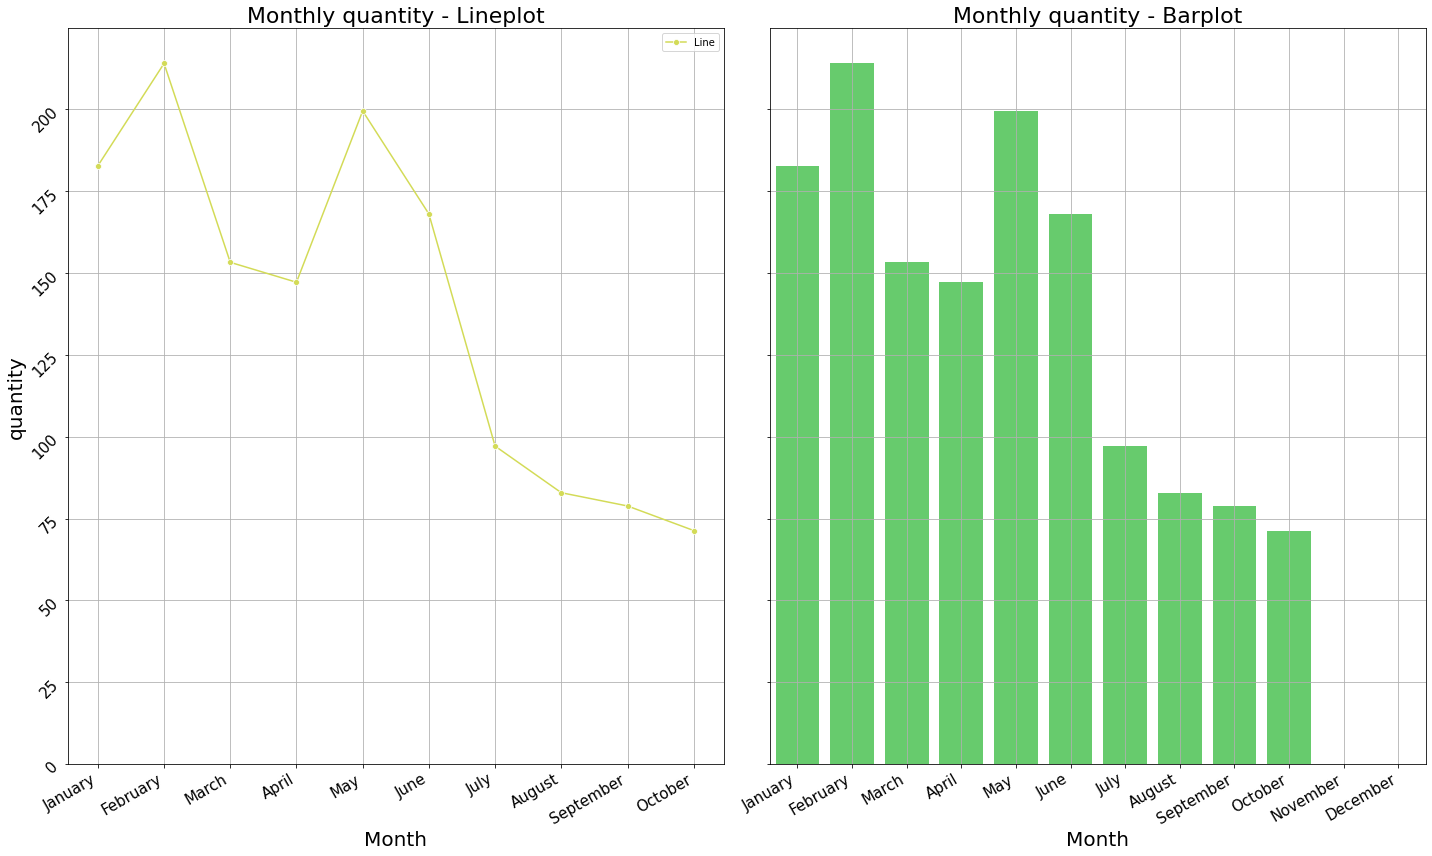

In [23]:
#evaluate average monthly quantity    
monthly_average("quantity")

**Findings**
- February and May show noticeable spikes in sales, suggesting a surge in demand during these months.
- After May, there is a sharp decline in sales, which continues all the way through to October, indicating a period of lower demand or potential stock availability issues.
- The spikes could be due to specific seasonal promotions, product launches, or market trends in February and May.

>#### 4.1.2 Average Monthly Sales Amount
This code uses the `monthly_average` function to visualize the average sales amount for each month. 

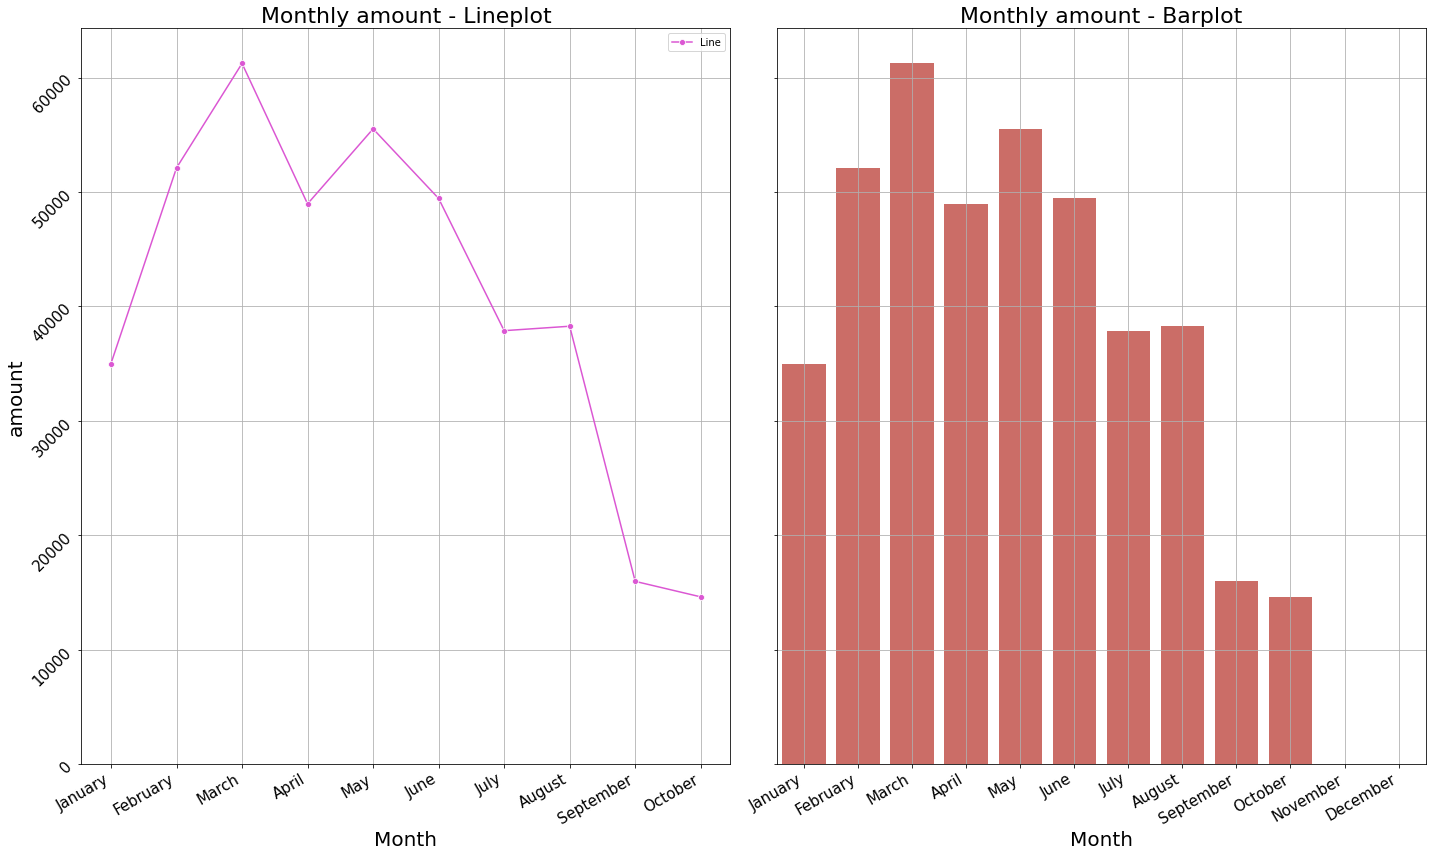

In [24]:
#plot average monthly sales amount
monthly_average("amount")

**Findings:**
- The average sales amount shows spikes in March and May, indicating possible seasonal demand or special events.
- Following May, the sales amount declines steadily through the year, reaching a low by October.
- These variations can be linked to changes in customer purchasing behavior, possibly due to external factors such as promotions, seasonality, or product availability.

>#### 4.1.2 Average Weekly Sales Amount and Quantity Sold
This code uses the `weekly_average` function to visualize the average sales amount for each week. 

In [25]:
## Average Weekly

#average weekly sales vs average sales amount

#fucntion for weekly average : Quantity sold, amount
def weekly_average(numerical_input):
    
    temp_df = df.copy()
    
    #weekly_avg = df.resample('W').mean()
    temp_df["Week"] = temp_df.index.isocalendar().week 
    weekly_avg = temp_df.groupby("Week")[numerical_input].mean().reset_index()
    
    palette = sns.color_palette("Set1")
    random_color = random.choice(palette)
    
    fig, ax = plt.subplots(figsize = (15,10))
    
    sns.lineplot(data = weekly_avg, x = 'Week', y = numerical_input, color = random_color, ax = ax, marker = 'o')
    ax.set_title(f'Weekly sales {numerical_input}', fontsize=22)
    ax.set_xlabel('Week', fontsize=20)
    ax.set_ylabel(f'{numerical_input}', fontsize=20)
    
    ax.tick_params(axis='both', labelsize=15)
    
    #make x axis labels more readable i.e prevent overlapping on x-axis 
    fig.autofmt_xdate()
    #plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
#df.resample(rule = 'W').mean()["quantity"].plot(kind='bar', figsize=(15,6))


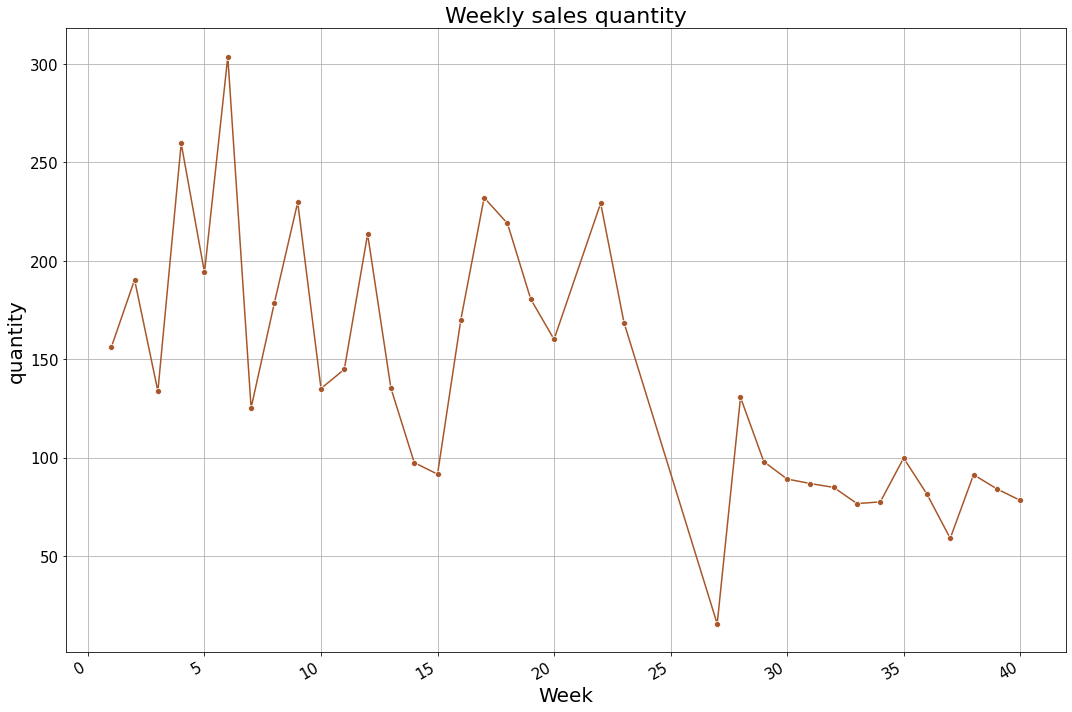

In [26]:
weekly_average("quantity")

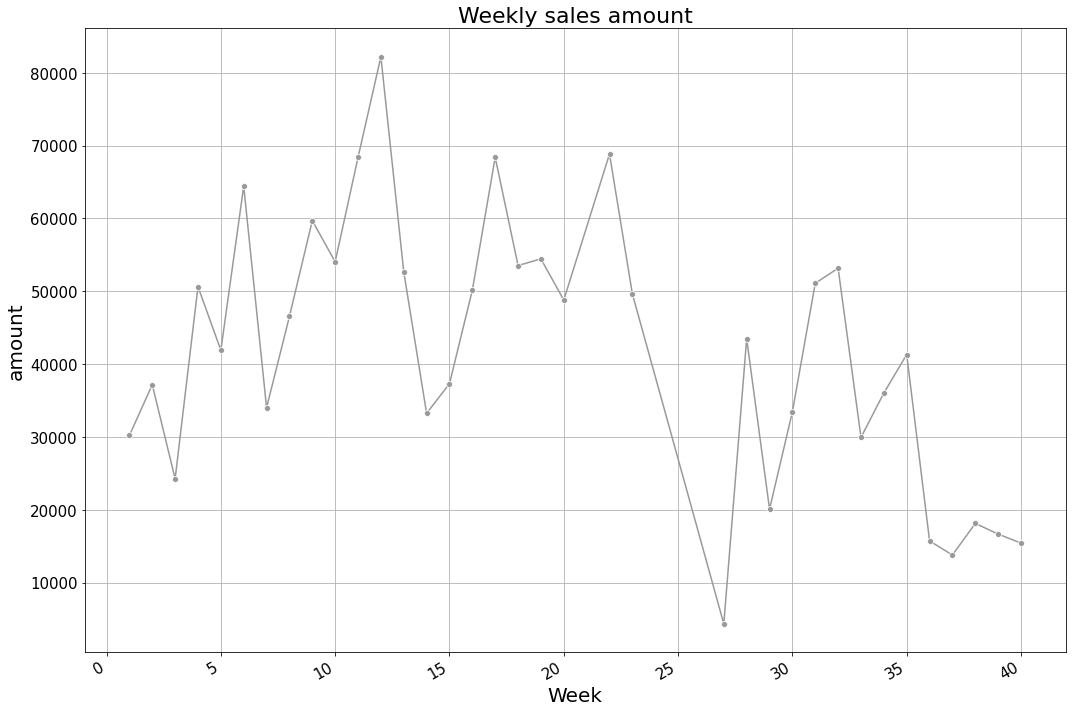

In [27]:
weekly_average("amount")

>#### 4.1.3 Average Daily Sales Amount and Quantity Sold
This code uses the `daily_average` function to visualize the average sales amount for each week. 

In [28]:
def daily_average(numerical_input, days_back=None):
    temp_df = df.copy()
    
    # Filter to recent days
    if days_back is not None:
        temp_df = temp_df.last(f"{days_back}D")  
        
    daily_avg = temp_df.resample('D').mean()
    
    palette = sns.color_palette("deep")
    random_color = random.choice(palette)
    
    fig, ax = plt.subplots(figsize=(15, 8))

    sns.lineplot(data=daily_avg, x=daily_avg.index, y=numerical_input, color=random_color, ax=ax)

    ax.set_title(f'Daily Sales {numerical_input} - Last {days_back} Days' if days_back else f'Daily Sales {numerical_input} - Full Data', fontsize=22)
    ax.set_xlabel('Date', fontsize=20)
    ax.set_ylabel(numerical_input, fontsize=20)
    ax.tick_params(axis='both', labelsize=14)
    fig.autofmt_xdate()
    
    plt.grid(True)
    plt.tight_layout()
    plt.show()


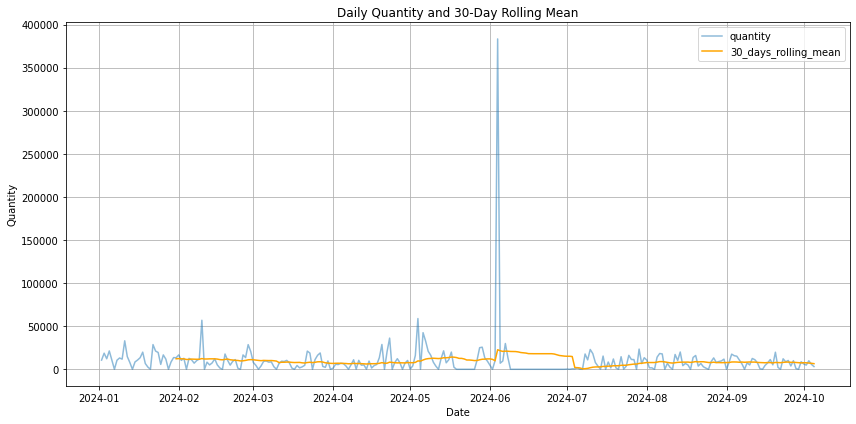

In [29]:
# Full range of dates
temp_df =df.copy()
full_range = pd.date_range(start=temp_df.index.min(), end=temp_df.index.max(), freq='D')

# Reindex to include all dates, filling missing with 0
daily_quantity = temp_df["quantity"].resample('D').sum().reindex(full_range, fill_value=0)

# Compute rolling mean again
rolling_mean = daily_quantity.rolling(window=30).mean()


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_quantity.index, daily_quantity, label='quantity', alpha=0.5)
plt.plot(rolling_mean.index, rolling_mean, label='30_days_rolling_mean', color='orange')
plt.legend()
plt.title('Daily Quantity and 30-Day Rolling Mean')
plt.ylabel('Quantity')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.show()


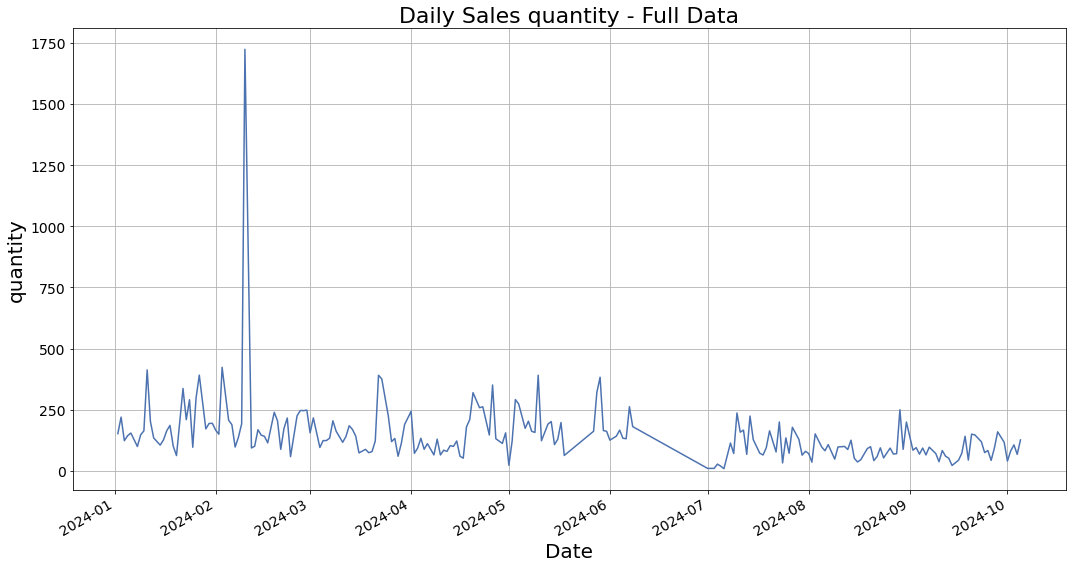

In [30]:
daily_average("quantity")

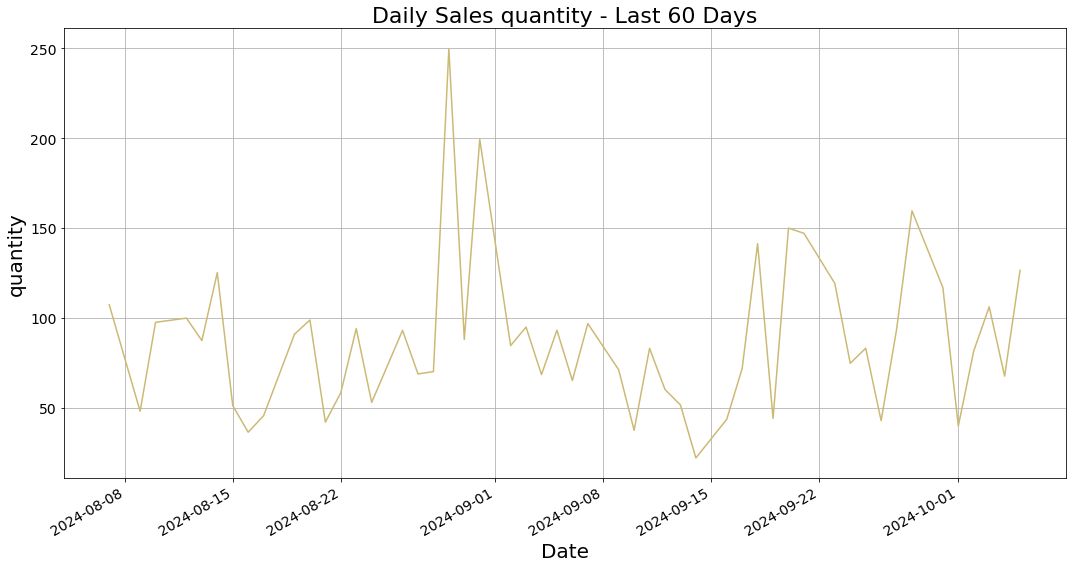

In [31]:
daily_average("quantity", days_back = 60)

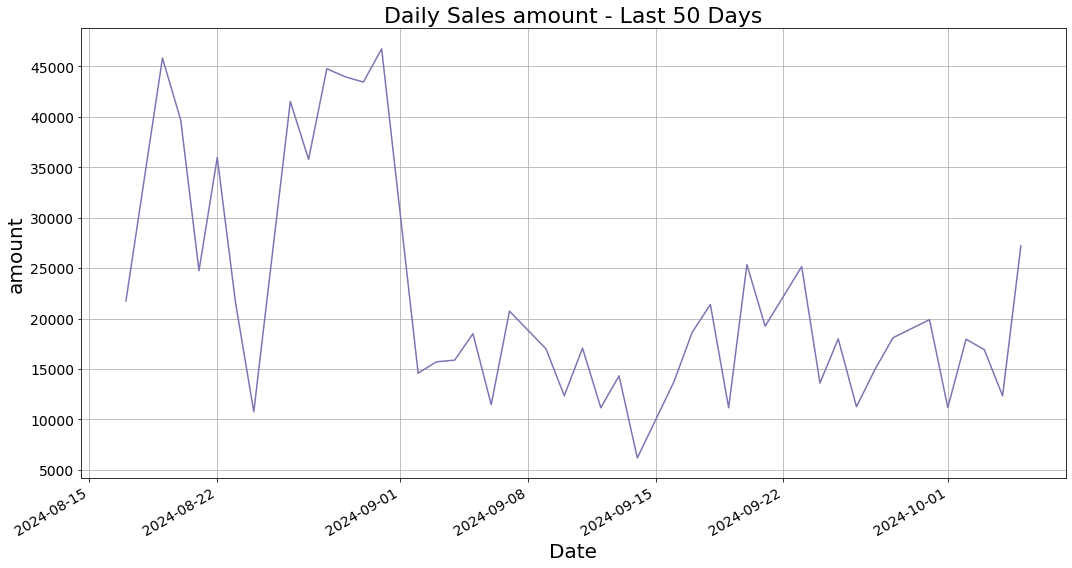

In [32]:
daily_average("amount", days_back = 50)

>####  4.1.4 Total Daily Sales Trend
We plot a graph to show the movement of total daily sales across the year, from January to September and indicate where our Forecasting is to start

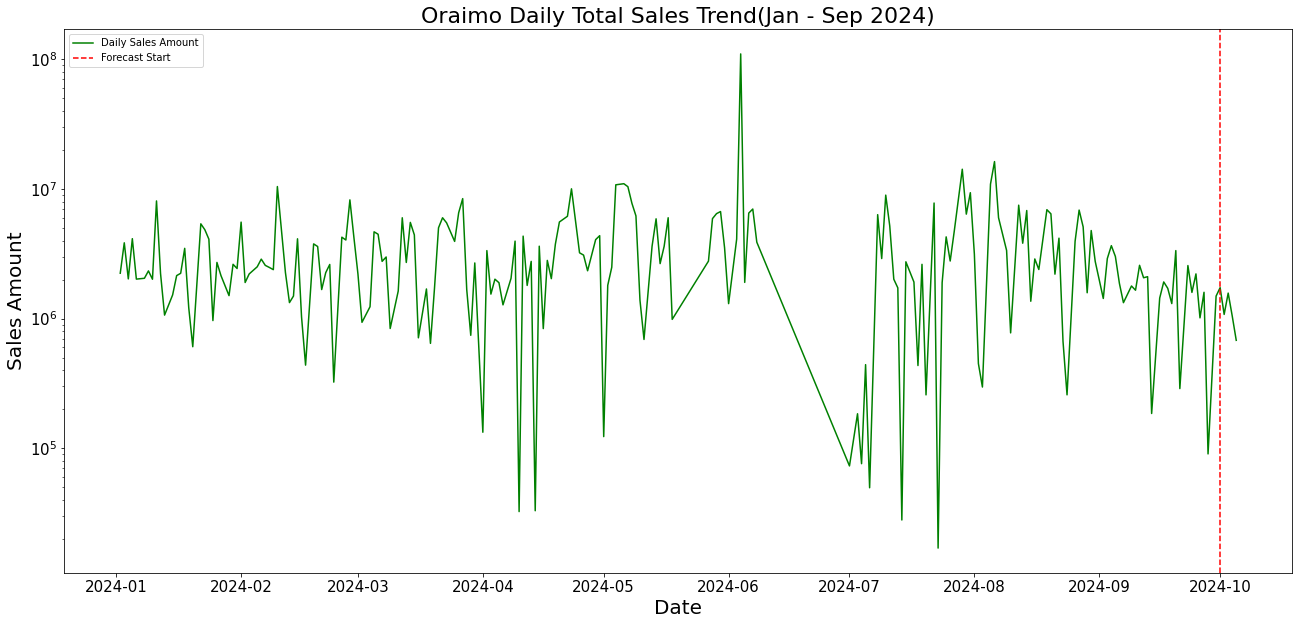

In [33]:
## Total Daily Sales Trend

# Plot sales trend
daily_sales = df.groupby(df.index.date)['amount'].sum().rename("total_sales")
daily_sales.index = pd.to_datetime(daily_sales.index)

plt.figure(figsize=(22,10))
plt.plot(daily_sales.index, daily_sales.values, label='Daily Sales Amount', color = "green")
plt.axvline(pd.to_datetime('2024-10-01'), color='r', linestyle='--', label='Forecast Start')
plt.title('Oraimo Daily Total Sales Trend(Jan - Sep 2024)', fontsize=22)
plt.xlabel('Date', fontsize=20)
plt.ylabel('Sales Amount', fontsize=20)
plt.yscale('log')
plt.tick_params(labelsize=15)
plt.legend()
plt.show()

**Findings:**

-  Forecasting stating point is indicated from Ocotber 2024
- There is a significant daily fluctuation in sales amounts throughout the period

>#### 4.1.5 Best and Worst Selling Products  
The plots below shows the top 10 best selling products across the market followed by the worst selling

<ipython-input-34-34f3def6d777>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_10_products.values, y = top_10_products.index, palette = "inferno")


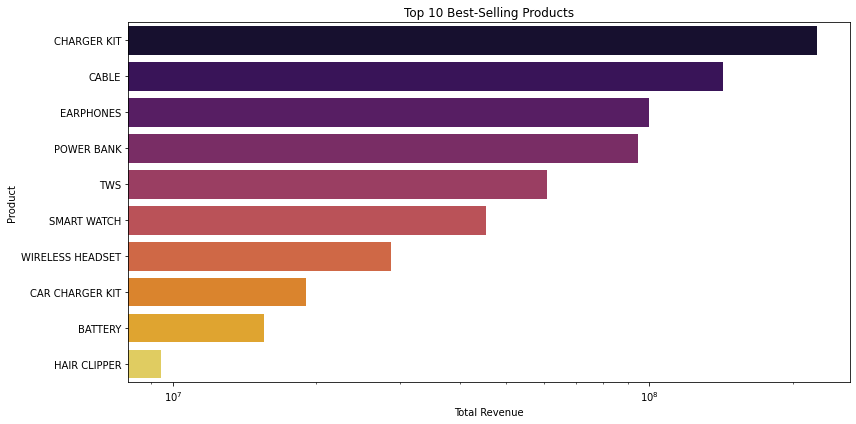

In [34]:
#best selling
product_sales = df.groupby("product_type")["amount"].sum().sort_values(ascending = False)

#top 10 best selling/fast-moving product categories in terms of quantity sold
top_10_products = product_sales.head(10)
plt.figure(figsize = (12,6))
sns.barplot(x = top_10_products.values, y = top_10_products.index, palette = "inferno")
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.xscale('log')
#plt.xlim(0, 100000) 
plt.tight_layout()
plt.show()

<ipython-input-35-5fbde0131254>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = bottom_10_products.values, y = bottom_10_products.index, palette = "deep")


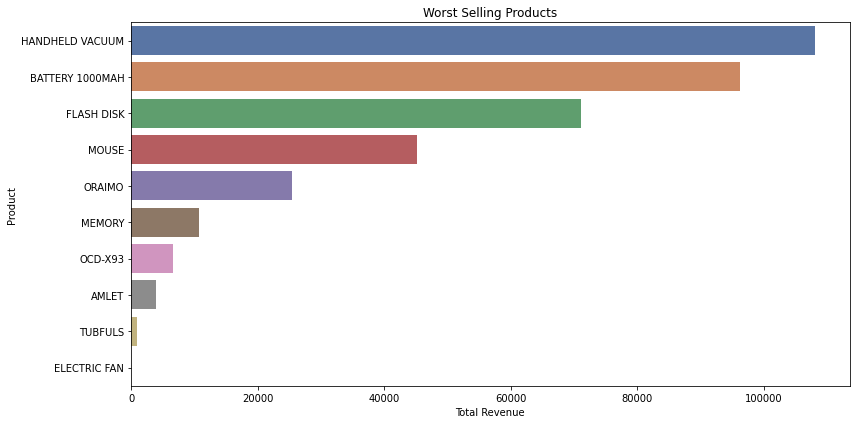

In [35]:
#worst selling
bottom_10_products = product_sales.tail(10)
plt.figure(figsize = (12,6))
sns.barplot(x = bottom_10_products.values, y = bottom_10_products.index, palette = "deep")
plt.title('Worst Selling Products')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
#plt.xscale('log')
#plt.xlim(0, 100000) 
plt.tight_layout()
plt.show()

**Findings:**
- The best selling products are Chargers, earphones and cables
- Worst selling products include goods such as Shavers and Memory Cards
- The it also indicates that Power Devices  and Audio Devices should be our most stocked goods

>#### 4.1.6 Most Common Products
The plot below shows the most common products sold

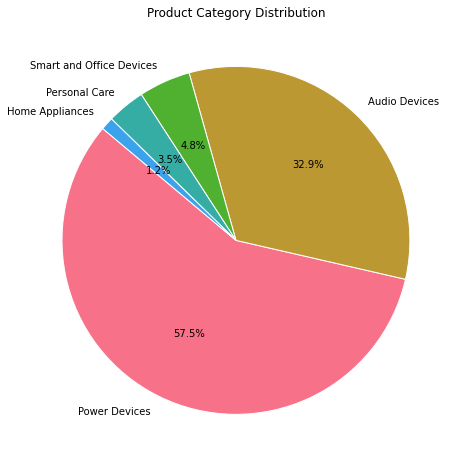

In [36]:
categories_performance = df['product_category'].value_counts()
categories_performance = categories_performance[categories_performance.index != 'Unknown']
percentages = (categories_performance / categories_performance.sum()) * 100

colors = sns.color_palette('husl')

plt.figure(figsize=(8, 8))
plt.pie(categories_performance,
        labels=categories_performance.index,
        autopct='%1.1f%%', 
        startangle=140,     
        colors=colors,
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'}) 
plt.title('Product Category Distribution')
plt.ylabel('')
plt.show()

**Findings:**
- The most popular category is the Power Devices category Containing goods such as Chargers and Power Cables
- 32.9% of the goods are the Audio Devices category including products such as Earphones
- Home appliances are the east popular occupying less than 2% of the products in the market

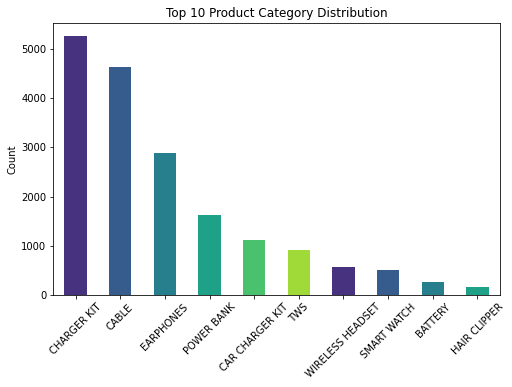

In [37]:
#top 10 product category distribution
##most common products being sold

top_10_distribution = df['product_type'].value_counts().head(10)
colors = sns.color_palette('viridis')
top_10_distribution.plot(kind='bar', title='Top 10 Product Category Distribution',
                         figsize=(8,5), color = colors)
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

**Findings:**
- The most popular product across the country is the Charger Kit and the Cable which is in the Power Devices category
- Earphones follow next and are present in the Audio Devices Category which was about 32% of the producs in the market

>### 4.1.7 Average Daily Sales per Day of the Week
We evaluate the average sales per individual days of the week i.e Monday, Tuesday, Wednesday ... etc

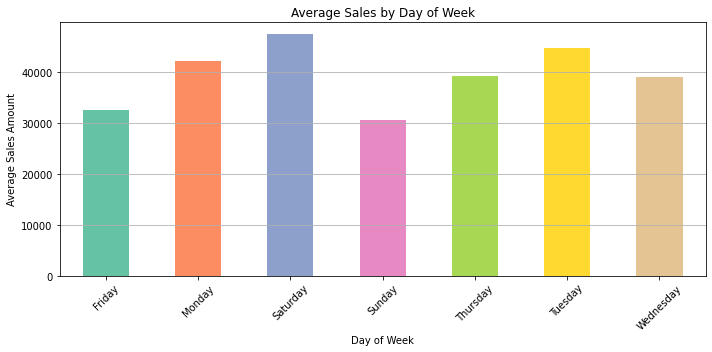

In [38]:
#AVERAGE SALES PER DAY OF THE WEEK
temp_df = df.copy()

temp_df["day"] = temp_df.index.day_name()
weekly_avg = temp_df.groupby("day")["amount"].mean()

#plot
colors = sns.color_palette('Set2')
plt.figure(figsize=(10, 5))
weekly_avg.plot(kind='bar', color=colors)
plt.title('Average Sales by Day of Week')
plt.ylabel('Average Sales Amount')
plt.xlabel('Day of Week')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

**Findings:**
- Saturdays have the highest foot traffic where average sales across the week is highest
- Sundays have the lowest average sales 
- A spike is noticed from Mondays through to Thursday where sales drop on Fridays and spike up on Saturdays
- The best perfoming weekend day is Saturday
- Weekend sales are higher than weekdays

### 4.2 Bivariate Analysis
Bivariate analysis involves examining the relationship between two variables to understand how one may affect the other.

>#### 4.2.1 Weekday vs Weekend Sales
This analysis compares average sales between weekends and weekdays.

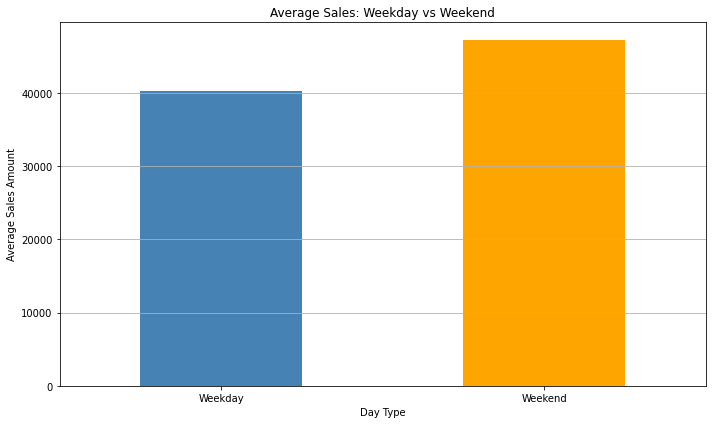

In [39]:
# Add Weekend Flag -> This distinguishes weekends from weekdays.
temp_df = df.copy()

temp_df['day_of_week'] = temp_df.index.day_name()
temp_df['is_weekend'] = temp_df['day_of_week'].isin(['Saturday', 'Sunday'])
temp_df['day_type'] = temp_df['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

# Groups by day type and calculate average sales
summary = temp_df.groupby('day_type')['amount'].mean()

# Plot the bar chart
summary.plot(kind='bar', color=['steelblue', 'orange'], figsize=(10, 6))
plt.title("Average Sales: Weekday vs Weekend")
plt.ylabel("Average Sales Amount")
plt.xlabel("Day Type")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

**Findings:**
- Weekend sales are higher than weekday sales, as shown by the average sales amount comparison.
- This suggests that customers are likely spending more on weekends, possibly due to higher foot traffic, more promotional activities, or people having more free time to shop.
- The difference in sales could be leveraged for planning inventory, staffing and marketing strategies to maximize sales during weekends.

>#### 4.2.2 Sales Price vs Quantity Sold
This analysis investigates the relationship between sales price and quantity sold, with amount (total sales revenue) used as an additional variable

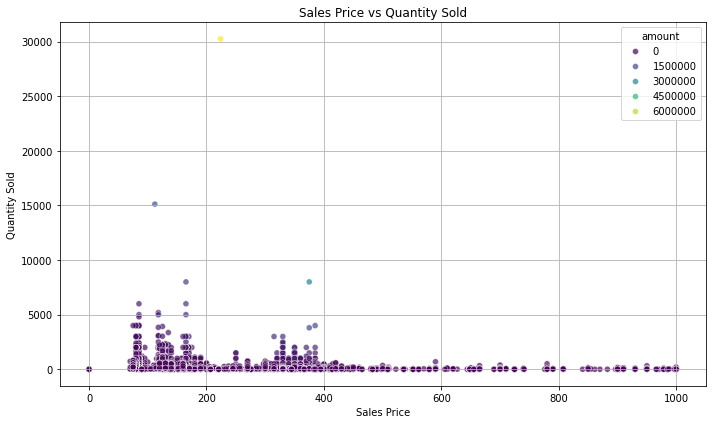

In [40]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = df, x = "sales_price", y = "quantity", hue = "amount", palette = "viridis", alpha = 0.7)
plt.title("Sales Price vs Quantity Sold")
plt.xlabel("Sales Price")
plt.ylabel("Quantity Sold")
plt.grid(True)
plt.tight_layout()
plt.show()

**Findings:**                                                                                                                   
- Most Sales Occur at Lower Price Points: The majority of the data points are clustered on the left side of the plot, indicating that most products are sold at relatively lower price points. This suggests that the customer base is more responsive to lower pricing, implying a potential opportunity for targeting price-sensitive customers.
- Quantity Sold is Generally Low: Most data points are concentrated near the bottom of the y-axis, representing low quantities sold.
- Few High Outliers: A few significant outliers can be identified, such as one product that sold approximately 30,000 units at a price under 200, marked yellow in the scatter plot, indicating it generated the highest amount.
- “Amount” Metric is Strongest in Outliers: The yellow points represent high amounts, which are typically associated with high-volume sales at lower or mid-price points.This suggests that the most impactful sales (in terms of revenue) come from a few high-volume, lower- or mid-priced products, potentially driven by bulk purchases or successful marketing campaigns.
                                

>#### 4.2.3 Correlation Analysis of Numeric Variables
This heatmap shows the correlation between `quantity`, `sales_price` and `amount`. The values range from -1 to 1.

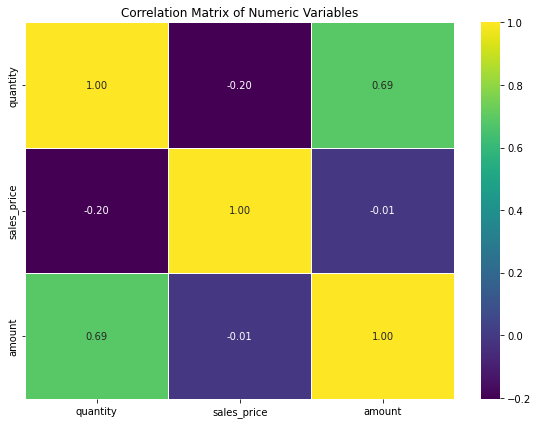

In [41]:
# Select numeric columns for correlation
numeric_cols = ['quantity', 'sales_price', 'amount']
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

**Findings**
- Quantity and Amount: A moderate positive correlation of 0.69 suggests that as quantity sold increases, the total amount (sales value) also tends to increase.
- Quantity and Sales Price: A weak negative correlation of -0.20 indicates that higher quantities are not strongly associated with higher sales prices.
- Sales Price and Amount: A very weak negative correlation of -0.01 suggests that there is virtually no relationship between sales price and the total amount.

>#### 4.2.4 Monthly vs Day-of-Week Sales Heatmap
This heatmap explores how sales amount varies across days of the week and months.
It allows for quick identification of patterns, such as consistently high or low sales on certain days or in specific months.

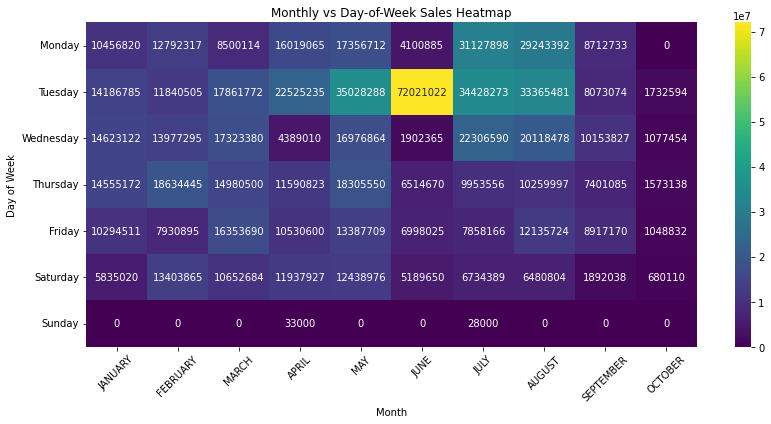

In [42]:
# Define the correct month order
month_order = ['JANUARY', 'FEBRUARY', 'MARCH', 'APRIL', 'MAY', 'JUNE', 
               'JULY', 'AUGUST', 'SEPTEMBER', 'OCTOBER']

# Ensure 'month' column is ordered correctly
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

# Extract day of week from index (date)
df['day_of_week'] = df.index.day_name()

# Create pivot table: sum of sales amount by day and month
heatmap_data = df.pivot_table(
    values='amount',
    index='day_of_week',
    columns='month',
    aggfunc='sum'
)

# Reorder days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(index=day_order)

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="viridis")
plt.title("Monthly vs Day-of-Week Sales Heatmap")
plt.xlabel("Month")
plt.ylabel("Day of Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Findings**
- High activity is observed on Tuesdays and Mondays, suggesting strong beginning-of-week demand.
- June recorded the highest sales, possibly indicating promotional campaigns or seasonal demand spikes.
- Lower sales on Sundays and Saturdays may reflect reduced business activity or customer engagement on those days

### 4.3 Multivariate Analysis
Multivariate analysis involves examining more than two variables at the same time to understand patterns, relationships, or structures in the data.

>#### 4.3.1 Dimensionality Reduction with PCA
We are using PCA to shrink our data from 3 numeric columns (amount, quantity and sales_price) down to 2 new columns (pca1 and pca2). This helps us visualize complex data in just two dimensions

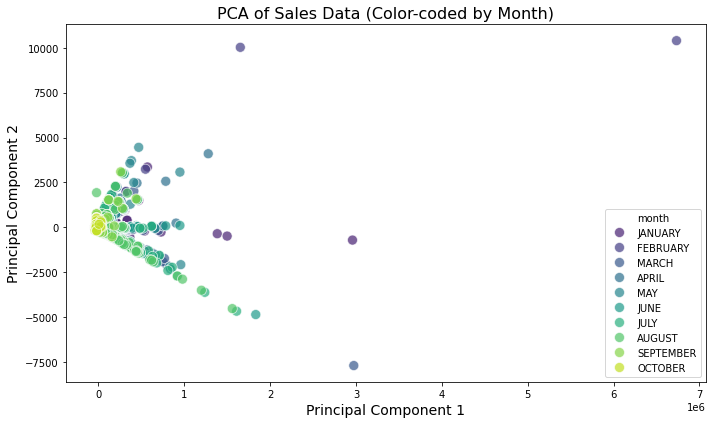

In [43]:
from sklearn.decomposition import PCA

# Selecting relevant features for PCA 
pca_features = df[['amount', 'quantity', 'sales_price']]

# Apply PCA
pca = PCA(n_components=2)  # Reduce to two components for visualization
pca_components = pca.fit_transform(pca_features)

# Add the PCA components to the dataframe
df['pca1'] = pca_components[:, 0]
df['pca2'] = pca_components[:, 1]


# Plotting PCA 
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pca1', y='pca2', data=df, hue='month', palette='viridis', s=100, alpha=0.7)

# Title and labels
plt.title('PCA of Sales Data (Color-coded by Month)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)

# Show plot
plt.tight_layout()
plt.show()


**Findings**
- Cluster near origin: Most sales data points cluster around the center, indicating consistent patterns across months (e.g. similar prices and quantities sold).
- Dispersed months: January and February show wider spread, likely due to seasonal demand or promotions.
- Seasonal clusters: May and September stand out, possibly marking peak periods with higher sales or pricing changes.
- PC1 spread: Principal Component 1 captures major variance—likely tied to quantity sold or sales price shifts

 ### 4.4 Partial autocorrelation (PACF)
 We plot the Partial Autocorrelation Fucntion Plot.  
 It can be imagined as the correlation between the series  and its lag, after exluding the contributions from intermediate lags

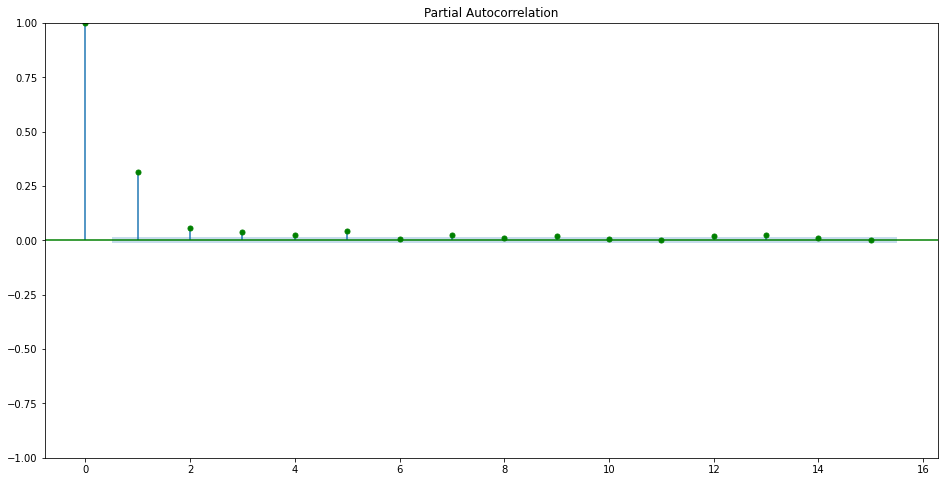

In [44]:
#import relevant libraries
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#Plot partial autocorrelation (P)
fig, ax = plt.subplots(figsize=(16, 8)) 
plot_pacf(df["quantity"].dropna(), lags = 15, color = "g", ax = ax)
plt.show()

**Findings**
- Based on the Partial Autocorrelation Fucntion(PACF) plot we should choose a p-value of 1  
- The first lag(lag 1) has a statistically significant spike that extends up to nearly 1.   
- After the first lag, the spikes quickly fall within a confidence interval and remain there suggesting that the direct relationshio with the series essentially stop after the first lag.  


### 4.5 Autocorrelation Plot (ACF)
We plot an ACF plot to show how our time series is correlated with its pas values(lags)

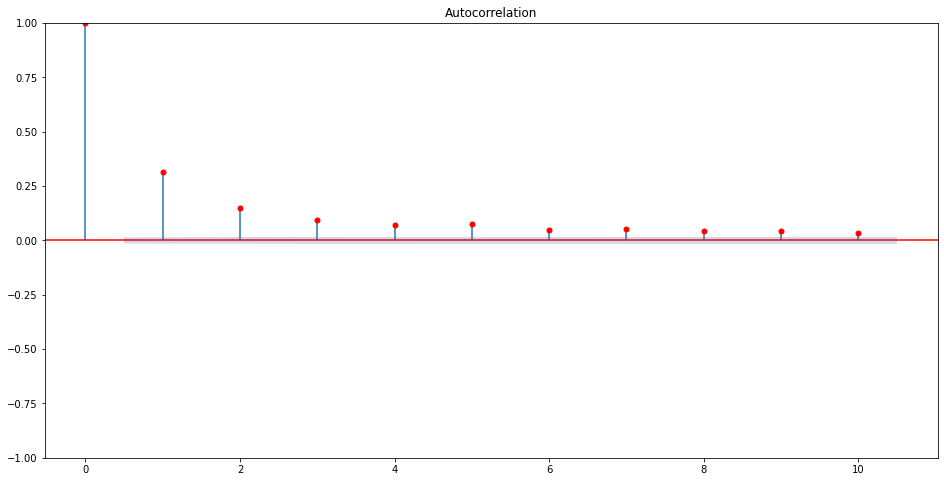

In [45]:
#Plot autocorrelation plot(Q)
fig, ax = plt.subplots(figsize=(16, 8)) 
plot_acf(df["quantity"].dropna(), lags = 10, color = "r", ax = ax);

**Findings**
- We have significant initial spikes indicating a significant positive autocorreation at the first  2 lags(lag 1 and lag 2). These spikes are clearly above zero.  
- After the second lag, the autocorrelation coefficients decrease and appear to be getting closer to zero, forming an exponential curve like shape.

## 5. Feature Engineering
We prepare the dataset for modelling

In [46]:
# 1. Aggregate to Daily Total Sales(Forecasting Daily Sales)
daily_sales = df['amount'].resample('D').sum().to_frame().rename(columns={'amount': 'daily_amount'})
#Groups my sales data by day ('D' stands for daily) and sums the total sales amount ('amount') for each day.

# Reset index to access the proper date as a column to extract day, week etc.
daily_sales = daily_sales.reset_index()

# 2. Time-Based Features -> Helps capture seasonality, monthly cycles, and weekday trends.
daily_sales['day'] = daily_sales['date'].dt.day
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['weekday'] = daily_sales['date'].dt.weekday
daily_sales['week'] = daily_sales['date'].dt.isocalendar().week.astype(int)
daily_sales['is_weekend'] = (daily_sales['weekday'] >= 5).astype(int)

# 3. Lag Features -> Introduces previous day’s, week’s, and 2-weeks-ago sales as past values of sales to capture recent trends(In our case Time Series benefits from Historical values)
daily_sales['lag_1'] = daily_sales['daily_amount'].shift(1)
daily_sales['lag_7'] = daily_sales['daily_amount'].shift(7)
daily_sales['lag_14'] = daily_sales['daily_amount'].shift(14)

# 4. Rolling Window Features -> Calculates the 7-day moving average and 7-day moving standard deviation thus Smoothens out short-term fluctuations and captures sales volatility and trends.
daily_sales['rolling_mean_7'] = daily_sales['daily_amount'].rolling(window=7).mean()
daily_sales['rolling_std_7'] = daily_sales['daily_amount'].rolling(window=7).std()

# 5. Marking specific holidays -> whereby Sales can spike or dip on holidays.
holidays = ['2024-03-31', '2024-11-29']  # Example: Easter & Black Friday -> this feature helps the model account for anomalies.
daily_sales['is_holiday'] = daily_sales['date'].isin(pd.to_datetime(holidays)).astype(int)

# 6. Dropping missing values introduced by lags and rolling windows
daily_sales.dropna(inplace=True)

#Set the index back to 'proper_date'
daily_sales.set_index('date', inplace=True)


# Quick check
daily_sales.head()

,daily_amount,day,month,weekday,week,is_weekend,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,is_holiday
date,,,,,,,,,,,,
2024-01-16,2146070.0,16,1,1,3,0,1522420.0,2333010.0,2239560.0,2.436856e+06,2.608720e+06,0
2024-01-17,2235965.0,17,1,2,3,0,2146070.0,2012135.0,3842525.0,2.468832e+06,2.604014e+06,0
2024-01-18,3482595.0,18,1,3,3,0,2235965.0,8081942.0,2024825.0,1.811782e+06,1.094231e+06,0
2024-01-19,1215436.0,19,1,4,3,0,3482595.0,2231080.0,4135795.0,1.666690e+06,1.096700e+06,0
2024-01-20,607090.0,20,1,5,3,1,1215436.0,1064345.0,2016785.0,1.601368e+06,1.150838e+06,0


C:\Users\user\anaconda3\envs\learn-env\lib\site-packages\xgboost\compat.py:93: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
C:\Users\user\anaconda3\envs\learn-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\envs\learn-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


📉 Naive Baseline - MAE: 398277.19, RMSE: 467336.11
📊 SARIMA - MAE: 1067364.23, RMSE: 1538944.19
⚡ XGBoost - MAE: 268945.77, RMSE: 295768.59


C:\Users\user\anaconda3\envs\learn-env\lib\site-packages\xgboost\data.py:173: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
<ipython-input-47-4afecd705498>:56: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
C:\Users\user\anaconda3\envs\learn-env\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


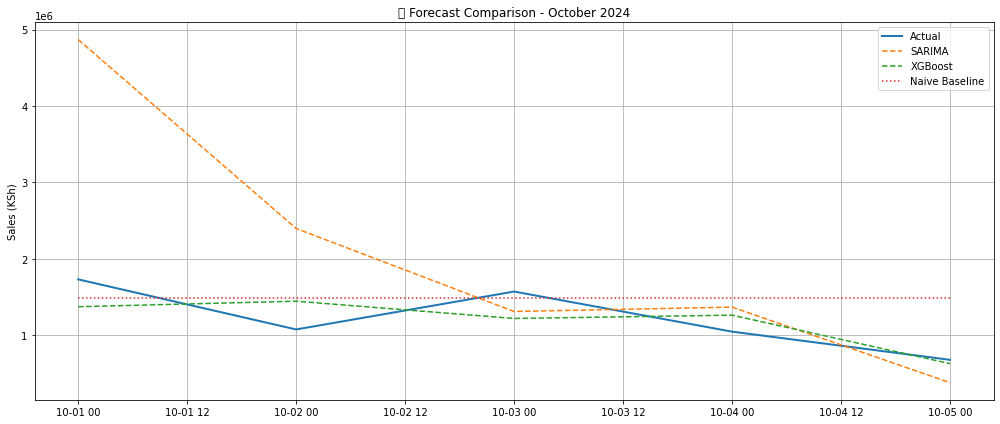

In [47]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import numpy as np
import matplotlib.pyplot as plt

# 1. Split into train (Jan–Sep) and test (Oct)
train = daily_sales[:'2024-09-30']['daily_amount']
test = daily_sales['2024-10-01':]['daily_amount']
#ARIMA inputs: train and test shows (only sales values, with no features)
#XGBoost inputs: X_train, X_test, y_train, y_test shows(features + target)

X = daily_sales[['day', 'month', 'weekday', 'week', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'is_holiday']]
y = daily_sales['daily_amount']
X_train = X[:'2024-09-30']
X_test = X['2024-10-01':]
y_train = y[:'2024-09-30']
y_test = y['2024-10-01':]

# 2. Baseline Model (Naive: yesterday = today)
naive_forecast = y_train.shift(1).reindex(y_test.index).fillna(method='ffill')
# Ensure naive_forecast does not contain NaN values before calculating metrics
naive_forecast = naive_forecast.fillna(y_train.iloc[-1])  # Fills remaining NaNs with the last value of y_train
naive_mae = mean_absolute_error(y_test, naive_forecast)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_forecast))
print(f"📉 Naive Baseline - MAE: {naive_mae:.2f}, RMSE: {naive_rmse:.2f}")
#Predicts each day’s sales as the same as the previous day’s.

# 3. SARIMA Model -> uses only the past values of sales, not the engineered features.
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,7)) #The seasonal order of (1,1,1,7) captures weekly seasonality (every 7 days).
sarima_results = sarima_model.fit()
sarima_forecast = sarima_results.predict(start=test.index[0], end=test.index[-1])
sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
print(f"📊 SARIMA - MAE: {sarima_mae:.2f}, RMSE: {sarima_rmse:.2f}")

# 4. XGBoost Model ->supervised learning model that uses the engineered features.
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
print(f"⚡ XGBoost - MAE: {xgb_mae:.2f}, RMSE: {xgb_rmse:.2f}")
#learns patterns from past trends, holidays, weekdays, etc.

# 5. Plot Comparisons ->The plot helps visualize how closely each model tracks the actual sales in October.
plt.figure(figsize=(14,6))
plt.plot(y_test, label='Actual', linewidth=2)
plt.plot(sarima_forecast, label='SARIMA', linestyle='--')
plt.plot(y_test.index, xgb_preds, label='XGBoost', linestyle='--')
plt.plot(y_test.index, naive_forecast, label='Naive Baseline', linestyle=':')
plt.title("🔍 Forecast Comparison - October 2024")
plt.ylabel("Sales (KSh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The visualization above the of actual vs predicted daily sales for October:

Blue Line (Actual Sales): Represents the real daily sales data in October 2024.

Orange Dashed Line (SARIMA): SARIMA initially overestimates sales, then aligns better with actuals towards the end of the shown period.

Green Dashed Line (XGBoost): The XGBoost model provides moderate forecasts, generally staying close to actual sales, especially after Oct 2.

Red Dotted Line (Naive Baseline): The naive forecast (previous day's sales = today’s sales) is flat and doesn’t adapt well to changing trends.

SARIMA struggles with the initial spike in sales.

XGBoost appears to be more responsive to daily variations and tracks the trend better after the first day.

Naive Baseline is simple but underperforms due to lack of dynamic behavior